## Installing/Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV 
from sklearn.preprocessing import StandardScaler

## Data Acquisition

In [2]:
data = pd.read_csv(filepath_or_buffer = "healthcare_dataset.csv")
data.shape

(10000, 15)

In [3]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [5]:
data.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [6]:
data.skew()

C:\Users\admin\AppData\Local\Temp\ipykernel_9192\1188251951.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  data.skew()


Age              -0.012148
Billing Amount    0.012721
Room Number       0.013370
dtype: float64

In [7]:
data.duplicated().any()

False

## Exploratory Data Analysis

1.Distribution of Test result.

In [8]:
data['Test Results'].value_counts()

Abnormal        3456
Inconclusive    3277
Normal          3267
Name: Test Results, dtype: int64

2.Distribution of Blood Group 

In [9]:
data['Blood Type'].value_counts()

AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: Blood Type, dtype: int64

3.Distribution of Gender

In [10]:
data['Gender'].value_counts()

Female    5075
Male      4925
Name: Gender, dtype: int64

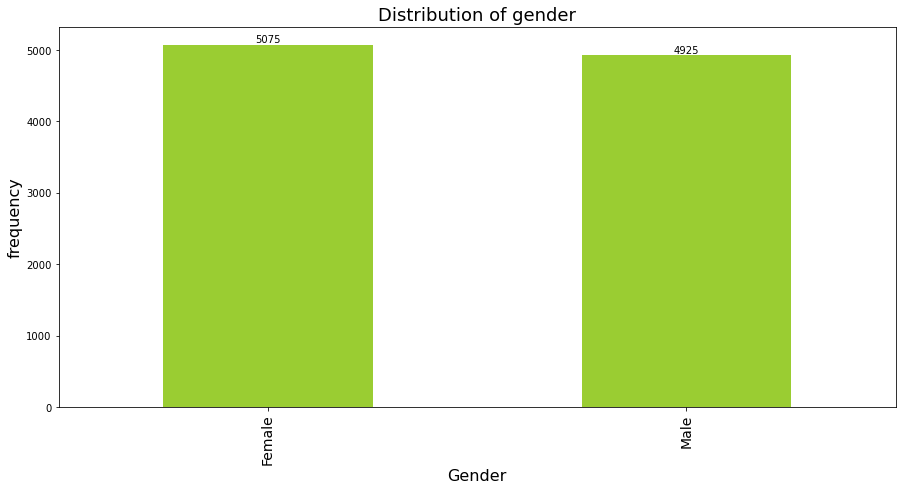

In [11]:
paper = plt.figure(figsize = [15,7])
ax = data['Gender'].value_counts().plot.bar(color='yellowgreen')
plt.xticks(size=14)
plt.xlabel(xlabel="Gender",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of gender",size=18)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

4.Distribution of Medical Condition

In [12]:
data['Medical Condition'].value_counts()

Asthma          1708
Cancer          1703
Hypertension    1688
Arthritis       1650
Obesity         1628
Diabetes        1623
Name: Medical Condition, dtype: int64

5.Distribution of Female patients on the basis of Medical Condition 

In [13]:
female_patients = data[data['Gender']=='Female']
female_patients.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
7,Patty Norman,55,Female,O-,Arthritis,2019-05-16,Brian Kennedy,Brown Inc,Blue Cross,13546.817249,384,Elective,2019-06-02,Aspirin,Normal
9,Sharon Perez,39,Female,O-,Asthma,2022-12-15,Jessica Bailey,Brown-Golden,Blue Cross,22788.236026,310,Urgent,2022-12-16,Aspirin,Normal
11,Mrs. Caroline Farrell,23,Female,O-,Hypertension,2019-06-09,William Miller,Rose Inc,Medicare,6185.903530,126,Emergency,2019-06-26,Paracetamol,Inconclusive
12,Christina Williams,85,Female,A+,Diabetes,2021-11-29,Laura Roberts,"Malone, Thompson and Mejia",Aetna,4835.945650,444,Elective,2021-12-14,Aspirin,Inconclusive


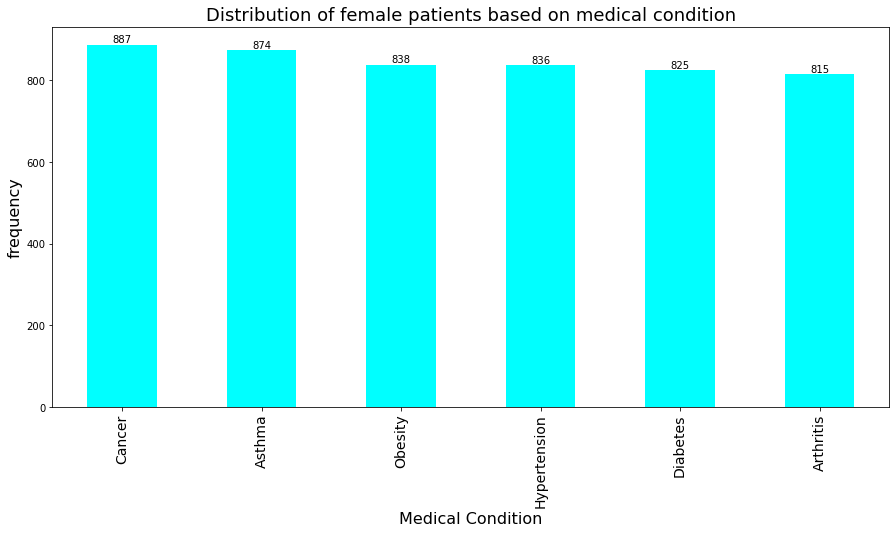

In [14]:
paper = plt.figure(figsize=[15,7])
ax = female_patients['Medical Condition'].value_counts().plot.bar(color='aqua')
plt.xticks(size=14)
plt.xlabel(xlabel="Medical Condition",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of female patients based on medical condition",size=18)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [15]:
female_patients['Medical Condition'].value_counts()

Cancer          887
Asthma          874
Obesity         838
Hypertension    836
Diabetes        825
Arthritis       815
Name: Medical Condition, dtype: int64

6.Distribution of Male patients on the basis of Medical Condition 

In [16]:
male_patients = data[data['Gender']=='Male']
male_patients.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal
5,Patrick Parker,41,Male,AB+,Arthritis,2020-08-20,Robin Green,Boyd PLC,Aetna,22522.363385,180,Urgent,2020-08-23,Aspirin,Abnormal


In [17]:
male_patients.shape

(4925, 15)

In [18]:
male_patients['Medical Condition'].value_counts()

Hypertension    852
Arthritis       835
Asthma          834
Cancer          816
Diabetes        798
Obesity         790
Name: Medical Condition, dtype: int64

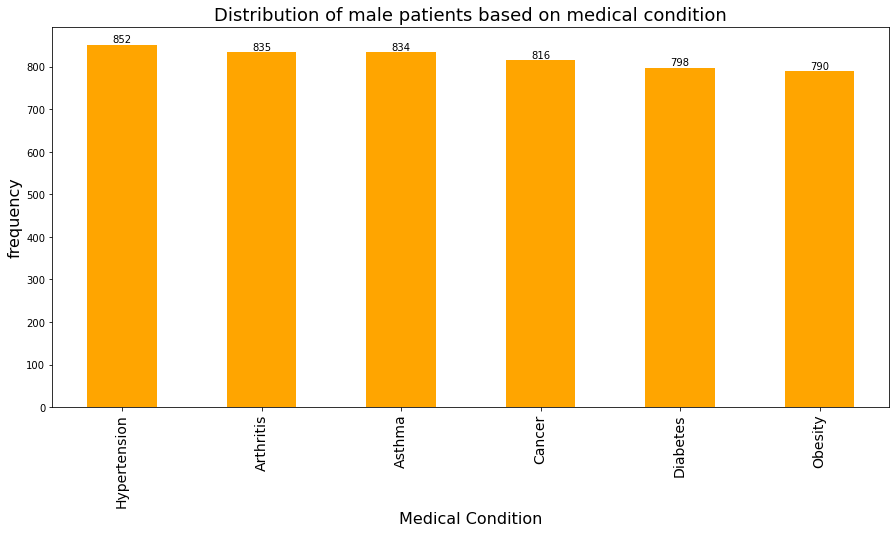

In [19]:
paper = plt.figure(figsize=[15,7])
ax1 = male_patients['Medical Condition'].value_counts().plot.bar(color='orange')
plt.xticks(size=14)
plt.xlabel(xlabel="Medical Condition",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of male patients based on medical condition",size=18)
for container in ax1.containers:
    ax1.bar_label(container)
plt.show()

7.Distribution of Female patients on the basis of blood Group 

In [20]:
female_patients['Blood Type'].value_counts()

AB-    671
O+     641
B+     640
AB+    637
B-     635
A-     633
A+     629
O-     589
Name: Blood Type, dtype: int64

8.Distribution of male patients on the basis of blood Group 

In [21]:
male_patients['Blood Type'].value_counts()

O-     655
AB+    621
B-     617
A+     612
O+     607
A-     605
AB-    604
B+     604
Name: Blood Type, dtype: int64

8.Distribution of male patients on the basis of Test Results

In [22]:
male_patients['Test Results'].value_counts()

Abnormal        1740
Normal          1604
Inconclusive    1581
Name: Test Results, dtype: int64

9.Distribution of female patients on the basis of Test Results

In [23]:
female_patients['Test Results'].value_counts()

Abnormal        1716
Inconclusive    1696
Normal          1663
Name: Test Results, dtype: int64

10.Distribution of Insurance Providers based on Abnormal test results

In [24]:
abnormal_data = data[data['Test Results']=='Abnormal']
abnormal_data.shape

(3456, 15)

In [25]:
abnormal_data['Insurance Provider'].value_counts()

UnitedHealthcare    702
Blue Cross          701
Aetna               698
Cigna               697
Medicare            658
Name: Insurance Provider, dtype: int64

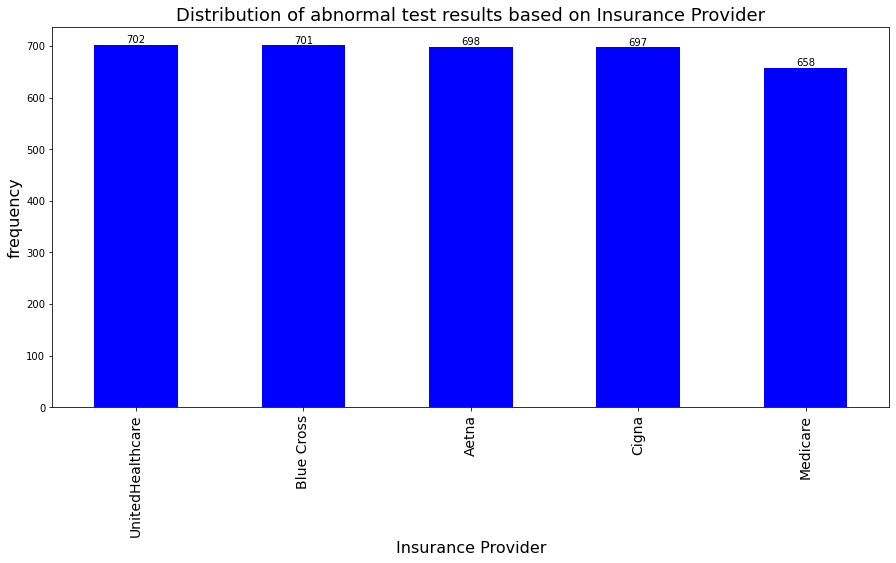

In [26]:
paper = plt.figure(figsize=[15,7])
ax2 = abnormal_data['Insurance Provider'].value_counts().plot.bar(color = 'blue')
plt.xticks(size=14)
plt.xlabel(xlabel="Insurance Provider",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of abnormal test results based on Insurance Provider",size=18)
for container in ax2.containers:
    ax2.bar_label(container)
plt.show()

11.Distribution of Medication: 

In [27]:
data['Medication'].value_counts()

Penicillin     2079
Lipitor        2015
Ibuprofen      1976
Aspirin        1968
Paracetamol    1962
Name: Medication, dtype: int64

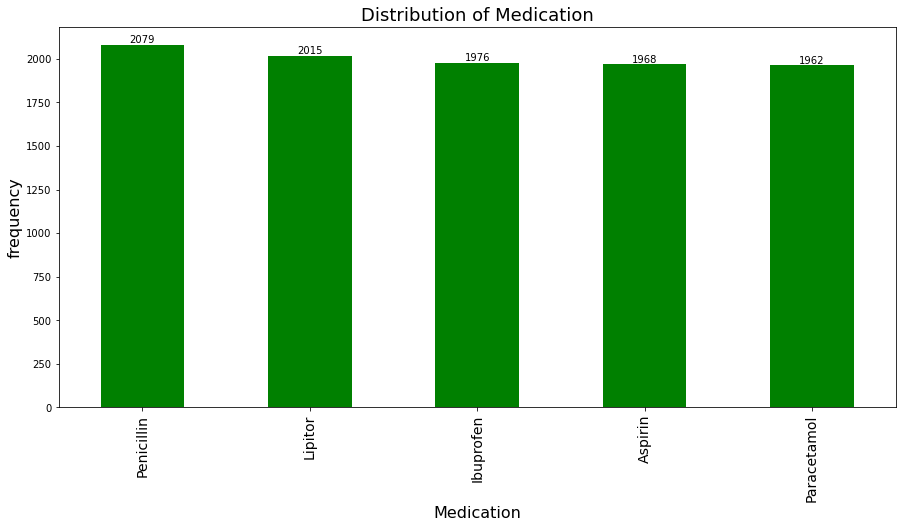

In [28]:
paper = plt.figure(figsize=[15,7])
ax3 = data['Medication'].value_counts().plot.bar(color = 'green')
plt.xticks(size=14)
plt.xlabel(xlabel="Medication",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of Medication",size=18)
for container in ax3.containers:
    ax3 .bar_label(container)
plt.show()

12.Distribution of abnormal test results  based on Medication

In [29]:
abnormal_data['Medication'].value_counts()

Lipitor        721
Penicillin     716
Paracetamol    685
Ibuprofen      680
Aspirin        654
Name: Medication, dtype: int64

13.Number of  Female patients who is taking lipitor medicine

In [30]:
female_patients['Medication'].value_counts()

Penicillin     1027
Paracetamol    1022
Lipitor        1016
Aspirin        1011
Ibuprofen       999
Name: Medication, dtype: int64

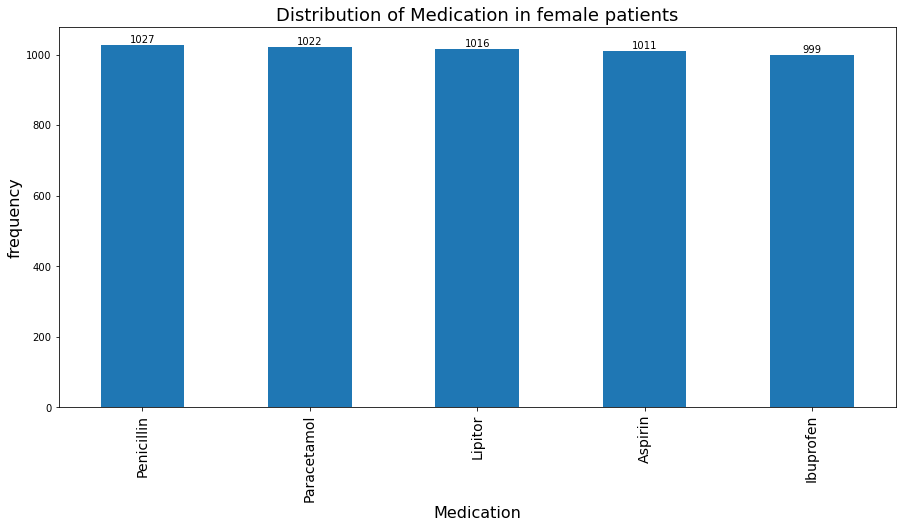

In [31]:
paper = plt.figure(figsize=[15,7])
ax4 = female_patients['Medication'].value_counts().plot.bar()
plt.xticks(size=14)
plt.xlabel(xlabel="Medication",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of Medication in female patients",size=18)
for container in ax4.containers:
    ax4 .bar_label(container)
plt.show()

14.Number of Male Patients is taking pencillin

In [32]:
male_patients['Medication'].value_counts()

Penicillin     1052
Lipitor         999
Ibuprofen       977
Aspirin         957
Paracetamol     940
Name: Medication, dtype: int64

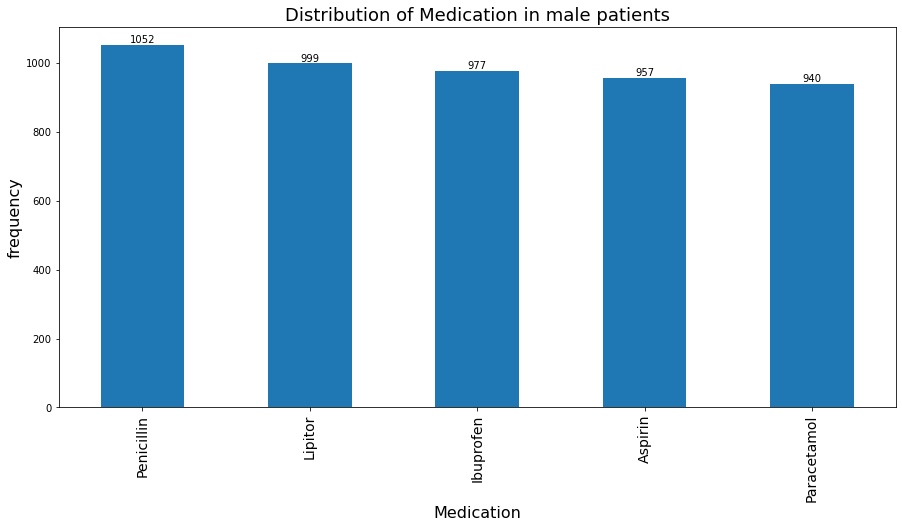

In [33]:
paper = plt.figure(figsize=[15,7])
ax5 = male_patients['Medication'].value_counts().plot.bar()
plt.xticks(size=14)
plt.xlabel(xlabel="Medication",size=16)
plt.ylabel(ylabel="frequency",size=16)
plt.title(label="Distribution of Medication in male patients",size=18)
for container in ax5.containers:
    ax5.bar_label(container)
plt.show()

15.Distribution of Age

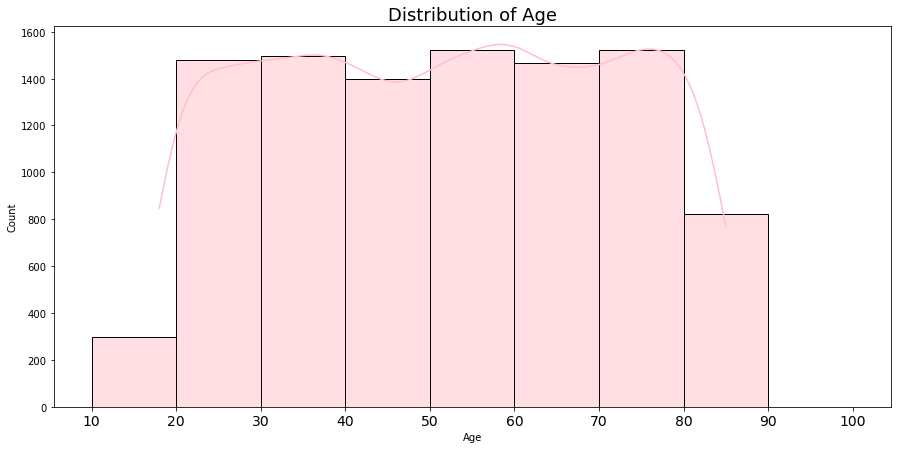

In [34]:
paper = plt.figure(figsize=[15,7])
sns.histplot(data= data,x='Age',kde=True,color='pink',binrange=(10,100),bins=9)
plt.xticks(ticks=range(10,110,10),size=14)
plt.title(label="Distribution of Age",size=18)
plt.show()

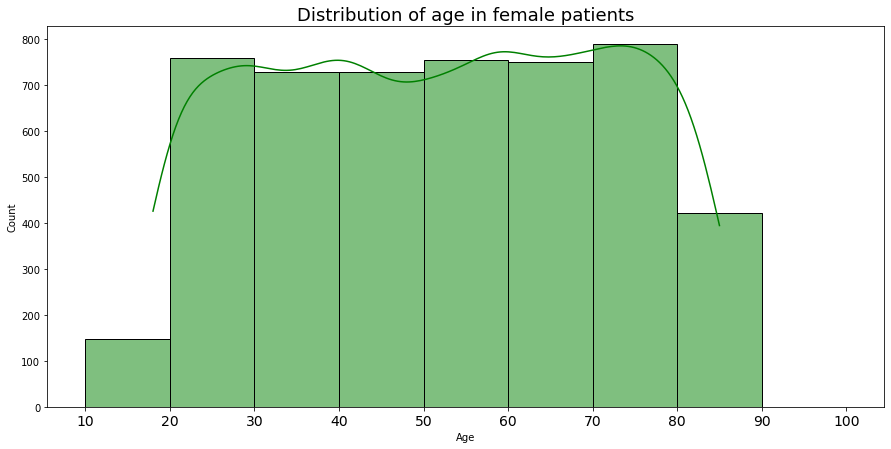

In [35]:
paper = plt.figure(figsize=[15,7])
sns.histplot(data= female_patients,x='Age',kde=True,color='green',binrange=(10,100),bins=9)
plt.xticks(ticks=range(10,110,10),size=14)
plt.title(label="Distribution of age in female patients",size=18)
plt.show()

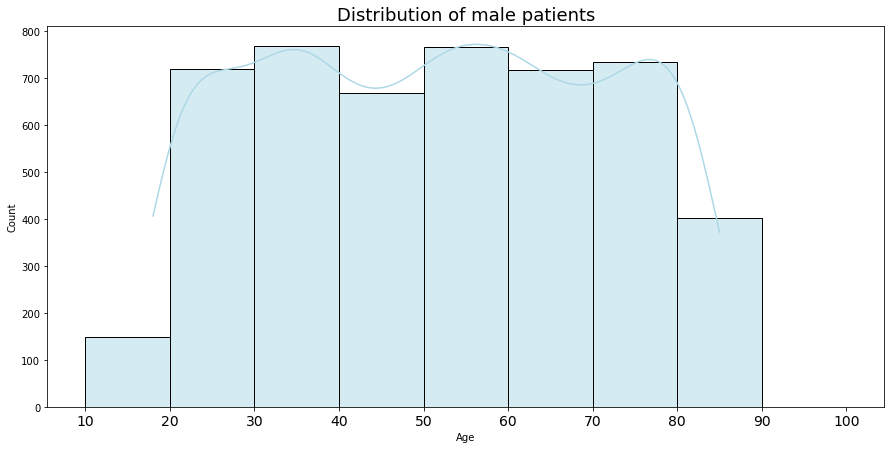

In [36]:
paper = plt.figure(figsize=[15,7])
sns.histplot(data= male_patients,x='Age',kde=True,color='lightblue',binrange=(10,100),bins=9)
plt.xticks(ticks=range(10,110,10),size=14)
plt.title(label="Distribution of male patients",size=18)
plt.show()

## Feature Engineering

In [37]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [38]:
drop_columns = ['Name','Billing Amount']
new_data = data.drop(labels=drop_columns,axis=1,inplace=False)
new_data.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,146,Elective,2022-12-01,Aspirin,Inconclusive
1,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,404,Emergency,2023-06-15,Lipitor,Normal
2,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,292,Emergency,2019-02-08,Lipitor,Normal
3,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,480,Urgent,2020-05-03,Penicillin,Abnormal
4,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,477,Urgent,2021-08-02,Paracetamol,Normal


In [39]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [40]:
new_data['Date of Admission'] = pd.to_datetime(data['Date of Admission'])

In [41]:
new_data['Discharge Date'] = pd.to_datetime(data['Discharge Date'])

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [43]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 10000 non-null  int64         
 1   Gender              10000 non-null  object        
 2   Blood Type          10000 non-null  object        
 3   Medical Condition   10000 non-null  object        
 4   Date of Admission   10000 non-null  datetime64[ns]
 5   Doctor              10000 non-null  object        
 6   Hospital            10000 non-null  object        
 7   Insurance Provider  10000 non-null  object        
 8   Room Number         10000 non-null  int64         
 9   Admission Type      10000 non-null  object        
 10  Discharge Date      10000 non-null  datetime64[ns]
 11  Medication          10000 non-null  object        
 12  Test Results        10000 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(9)
memor

In [44]:
new_data['Year'] = new_data['Date of Admission'].dt.year

In [45]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Age                 10000 non-null  int64         
 1   Gender              10000 non-null  object        
 2   Blood Type          10000 non-null  object        
 3   Medical Condition   10000 non-null  object        
 4   Date of Admission   10000 non-null  datetime64[ns]
 5   Doctor              10000 non-null  object        
 6   Hospital            10000 non-null  object        
 7   Insurance Provider  10000 non-null  object        
 8   Room Number         10000 non-null  int64         
 9   Admission Type      10000 non-null  object        
 10  Discharge Date      10000 non-null  datetime64[ns]
 11  Medication          10000 non-null  object        
 12  Test Results        10000 non-null  object        
 13  Year                10000 non-null  int64      

In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [47]:
new_data.head()

,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Room Number,Admission Type,Discharge Date,Medication,Test Results,Year
0,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,146,Elective,2022-12-01,Aspirin,Inconclusive,2022
1,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,404,Emergency,2023-06-15,Lipitor,Normal,2023
2,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,292,Emergency,2019-02-08,Lipitor,Normal,2019
3,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,480,Urgent,2020-05-03,Penicillin,Abnormal,2020
4,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,477,Urgent,2021-08-02,Paracetamol,Normal,2021


In [48]:
drop_columns = ['Date of Admission','Discharge Date']
new_data.drop(labels=drop_columns,axis=1,inplace=True)
new_data.head()

,Age,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Room Number,Admission Type,Medication,Test Results,Year
0,81,Female,O-,Diabetes,Patrick Parker,Wallace-Hamilton,Medicare,146,Elective,Aspirin,Inconclusive,2022
1,35,Male,O+,Asthma,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,404,Emergency,Lipitor,Normal,2023
2,61,Male,B-,Obesity,Paul Baker,Walton LLC,Medicare,292,Emergency,Lipitor,Normal,2019
3,49,Male,B-,Asthma,Brian Chandler,Garcia Ltd,Medicare,480,Urgent,Penicillin,Abnormal,2020
4,51,Male,O-,Arthritis,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,477,Urgent,Paracetamol,Normal,2021


In [49]:
drop_columns = ['Doctor','Hospital','Room Number']
new_data.drop(labels=drop_columns,axis=1,inplace=True)
new_data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results,Year
0,81,Female,O-,Diabetes,Medicare,Elective,Aspirin,Inconclusive,2022
1,35,Male,O+,Asthma,UnitedHealthcare,Emergency,Lipitor,Normal,2023
2,61,Male,B-,Obesity,Medicare,Emergency,Lipitor,Normal,2019
3,49,Male,B-,Asthma,Medicare,Urgent,Penicillin,Abnormal,2020
4,51,Male,O-,Arthritis,UnitedHealthcare,Urgent,Paracetamol,Normal,2021


In [50]:
X = new_data.drop(labels='Test Results',axis=1)
y = new_data['Test Results']

In [51]:
X.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Year
0,81,Female,O-,Diabetes,Medicare,Elective,Aspirin,2022
1,35,Male,O+,Asthma,UnitedHealthcare,Emergency,Lipitor,2023
2,61,Male,B-,Obesity,Medicare,Emergency,Lipitor,2019
3,49,Male,B-,Asthma,Medicare,Urgent,Penicillin,2020
4,51,Male,O-,Arthritis,UnitedHealthcare,Urgent,Paracetamol,2021


In [52]:
y.head()

0    Inconclusive
1          Normal
2          Normal
3        Abnormal
4          Normal
Name: Test Results, dtype: object

In [53]:
new_data['Medication'].unique()

array(['Aspirin', 'Lipitor', 'Penicillin', 'Paracetamol', 'Ibuprofen'],
      dtype=object)

In [54]:
categorical_cols = ['Age','Gender','Blood Type','Medical Condition','Insurance Provider','Admission Type','Medication'] 
X = pd.get_dummies(X)
X.head()

,Age,Year,Gender_Female,Gender_Male,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,81,2022,1,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,0,0
1,35,2023,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,0
2,61,2019,0,1,0,0,0,0,0,1,...,1,0,0,1,0,0,0,1,0,0
3,49,2020,0,1,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,1
4,51,2021,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,0


In [55]:
y.head()

0    Inconclusive
1          Normal
2          Normal
3        Abnormal
4          Normal
Name: Test Results, dtype: object

## Model Building

## Logistic Regression

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)
print(f"X_train.shape ::: {X_train.shape}")
print(f"X_test.shape ::: {X_test.shape}")
print(f"y_train.shape ::: {y_train.shape}")
print(f"y_test.shape ::: {y_test.shape}")

X_train.shape ::: (6700, 31)
X_test.shape ::: (3300, 31)
y_train.shape ::: (6700,)
y_test.shape ::: (3300,)


In [57]:
lr = LogisticRegression(n_jobs=-1).fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

## Model Evaluation for Logistic Regression 

In [58]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       0.37      0.55      0.44      2315
Inconclusive       0.35      0.21      0.26      2196
      Normal       0.35      0.30      0.33      2189

    accuracy                           0.36      6700
   macro avg       0.36      0.36      0.34      6700
weighted avg       0.36      0.36      0.35      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.35      0.52      0.42      1141
Inconclusive       0.34      0.20      0.25      1081
      Normal       0.34      0.29      0.31      1078

    accuracy                           0.34      3300
   macro avg       0.34      0.34      0.33      3300
weighted avg       0.34      0.34      0.33      3300



## Decision  Trees

In [59]:
dt = DecisionTreeClassifier(random_state=42,class_weight ='balanced').fit(X_train,y_train)
y_train_pred1 = dt.predict(X_train)
y_test_pred1 = dt.predict(X_test)

## Model Evaluation for Decision Trees

In [60]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred1))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred1))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       1.00      1.00      1.00      2315
Inconclusive       1.00      1.00      1.00      2196
      Normal       1.00      1.00      1.00      2189

    accuracy                           1.00      6700
   macro avg       1.00      1.00      1.00      6700
weighted avg       1.00      1.00      1.00      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.34      0.34      0.34      1141
Inconclusive       0.32      0.31      0.32      1081
      Normal       0.32      0.33      0.32      1078

    accuracy                           0.33      3300
   macro avg       0.33      0.33      0.33      3300
weighted avg       0.33      0.33      0.33      3300



## Random Forest

In [61]:
rf = RandomForestClassifier(random_state=42,class_weight ='balanced').fit(X_train,y_train)
y_train_pred2 = rf.predict(X_train)
y_test_pred2 = rf.predict(X_test)

## Model Evaluation for Random Forest 

In [62]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred2))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred2))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       1.00      1.00      1.00      2315
Inconclusive       1.00      1.00      1.00      2196
      Normal       1.00      1.00      1.00      2189

    accuracy                           1.00      6700
   macro avg       1.00      1.00      1.00      6700
weighted avg       1.00      1.00      1.00      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.36      0.39      0.37      1141
Inconclusive       0.31      0.31      0.31      1081
      Normal       0.33      0.30      0.32      1078

    accuracy                           0.34      3300
   macro avg       0.33      0.33      0.33      3300
weighted avg       0.33      0.34      0.33      3300



## GridSearch CV

In [63]:
param_grid = {'max_depth':[5,6,7,8,9,10,11,12,13,14,15,20,30,40,45,55,60,70,80,90,100]}
clf = GridSearchCV(rf, param_grid,n_jobs = -1)
clf.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                                       20, 30, 40, 45, 55, 60, 70, 80, 90,
                                       100]})

In [64]:
bgcv = clf.best_params_
print(f"bgcv:::{bgcv}")

bgcv:::{'max_depth': 13}


In [65]:
y_train_pred3 = clf.predict(X_train)
y_test_pred3 = clf.predict(X_test)

## Model Evaluation after grid search CV

In [66]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred3))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred3))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       0.99      0.99      0.99      2315
Inconclusive       0.99      0.99      0.99      2196
      Normal       0.99      0.99      0.99      2189

    accuracy                           0.99      6700
   macro avg       0.99      0.99      0.99      6700
weighted avg       0.99      0.99      0.99      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.34      0.35      0.35      1141
Inconclusive       0.30      0.30      0.30      1081
      Normal       0.33      0.31      0.32      1078

    accuracy                           0.32      3300
   macro avg       0.32      0.32      0.32      3300
weighted avg       0.32      0.32      0.32      3300



## Naive Bayes Theorem

In [67]:
scaler = StandardScaler()
scaled_data= scaler.fit_transform(X,y)
scaled_df = pd.DataFrame(scaled_data, columns =X.columns)

In [68]:
scaled_df.head()

,Age,Year,Gender_Female,Gender_Male,Blood Type_A+,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Elective,Admission Type_Emergency,Admission Type_Urgent,Medication_Aspirin,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,1.508465,0.807912,0.985111,-0.985111,-0.376408,-0.375888,-0.379345,-0.382272,-0.376927,-0.378310,...,2.048122,-0.496560,1.443785,-0.712470,-0.716302,2.020223,-0.496247,-0.502343,-0.494055,-0.512315
1,-0.839912,1.500448,-1.015114,1.015114,-0.376408,-0.375888,-0.379345,-0.382272,-0.376927,-0.378310,...,-0.488252,2.013855,-0.692624,1.403568,-0.716302,-0.494995,-0.496247,1.990673,-0.494055,-0.512315
2,0.487431,-1.269695,-1.015114,1.015114,-0.376408,-0.375888,-0.379345,-0.382272,-0.376927,2.643335,...,2.048122,-0.496560,-0.692624,1.403568,-0.716302,-0.494995,-0.496247,1.990673,-0.494055,-0.512315
3,-0.125189,-0.577159,-1.015114,1.015114,-0.376408,-0.375888,-0.379345,-0.382272,-0.376927,2.643335,...,2.048122,-0.496560,-0.692624,-0.712470,1.396060,-0.494995,-0.496247,-0.502343,-0.494055,1.951923
4,-0.023086,0.115376,-1.015114,1.015114,-0.376408,-0.375888,-0.379345,-0.382272,-0.376927,-0.378310,...,-0.488252,2.013855,-0.692624,-0.712470,1.396060,-0.494995,-0.496247,-0.502343,2.024065,-0.512315


In [69]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(scaled_df, y, test_size=0.33, random_state=42)
print(f"X_train1.shape ::: {X_train1.shape}")
print(f"X_test1.shape ::: {X_test1.shape}")
print(f"y_train1.shape ::: {y_train1.shape}")
print(f"y_test1.shape ::: {y_test1.shape}")

X_train1.shape ::: (6700, 31)
X_test1.shape ::: (3300, 31)
y_train1.shape ::: (6700,)
y_test1.shape ::: (3300,)


In [70]:
gnb = GaussianNB().fit(X_train1,y_train1)
y_train_pred4 = gnb.predict(X_train1)
y_test_pred4 = gnb.predict(X_test1)

## Model Evaluation for Naive Bayes

In [71]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred4))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred4))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       0.34      0.37      0.36      2315
Inconclusive       0.31      0.31      0.31      2196
      Normal       0.33      0.30      0.31      2189

    accuracy                           0.33      6700
   macro avg       0.33      0.33      0.33      6700
weighted avg       0.33      0.33      0.33      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.35      0.39      0.37      1141
Inconclusive       0.33      0.31      0.32      1081
      Normal       0.32      0.30      0.31      1078

    accuracy                           0.33      3300
   macro avg       0.33      0.33      0.33      3300
weighted avg       0.33      0.33      0.33      3300



## K Nearest Neighbour Algorithm

In [81]:
knc = KNeighborsClassifier(n_neighbors=7,metric="euclidean",n_jobs=-1).fit(X_train1,y_train1)
y_train_pred5 = knc.predict(X_train1)
y_test_pred5 = knc.predict(X_test1)

## Model Evaluation for K Nearest Neighbour Algorithm

In [82]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred5))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred5))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       0.35      0.42      0.38      2315
Inconclusive       0.33      0.33      0.33      2196
      Normal       0.32      0.25      0.28      2189

    accuracy                           0.33      6700
   macro avg       0.33      0.33      0.33      6700
weighted avg       0.33      0.33      0.33      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.35      0.44      0.39      1141
Inconclusive       0.34      0.35      0.34      1081
      Normal       0.33      0.24      0.28      1078

    accuracy                           0.34      3300
   macro avg       0.34      0.34      0.34      3300
weighted avg       0.34      0.34      0.34      3300



## Grid Search CV

In [74]:
#param_grid_knn = {'n_neighbors': list(range(2, 20)),
#                  'metric': ['euclidean','manhattan'],
#                  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
#                  'p': list(range(1,6)),
#                  'weights': ["uniform", "distance"]}

#knc1 = KNeighborsClassifier(n_jobs=-1)

#clf = GridSearchCV(knc1, param_grid_knn,n_jobs = -1)
#clf.fit(X_train1,y_train1)
#y_train_pred6 = clf.predict(X_train1)
#y_test_pred6 = clf.predict(X_test1)

In [85]:
param_grid_knn = {'n_neighbors': list(range(2, 20)),
                  'metric': ['euclidean','manhattan','hamming'],
                  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                  'weights': ["uniform", "distance"]}

knc1 = KNeighborsClassifier(n_jobs=-1)

clf = GridSearchCV(knc1, param_grid_knn,n_jobs = -1)
clf.fit(X_train1,y_train1)
y_train_pred6 = clf.predict(X_train1)
y_test_pred6 = clf.predict(X_test1)

C:\Users\admin\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
180 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\admin\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py", line 198, in fit
    return self._fit(X, y)
  File "C:\Users\admin\anaconda3\lib\site-packages\sklearn\neighbors\_base.py", line 437, in _fit
    self._check_algorithm_metric()
  File "C:\Users\admin\anaconda3\lib\si

## Model Evaluation after grid search CV

In [86]:
print("**********Train Data***********")
print(classification_report(y_train, y_train_pred6))
print("**********Test Data***********")
print(classification_report(y_test, y_test_pred6))

**********Train Data***********
              precision    recall  f1-score   support

    Abnormal       0.34      0.56      0.43      2315
Inconclusive       0.33      0.33      0.33      2196
      Normal       0.31      0.11      0.16      2189

    accuracy                           0.34      6700
   macro avg       0.33      0.33      0.30      6700
weighted avg       0.33      0.34      0.31      6700

**********Test Data***********
              precision    recall  f1-score   support

    Abnormal       0.35      0.59      0.44      1141
Inconclusive       0.33      0.32      0.32      1081
      Normal       0.36      0.12      0.18      1078

    accuracy                           0.35      3300
   macro avg       0.35      0.34      0.31      3300
weighted avg       0.35      0.35      0.32      3300

